# DQ Rules Engine

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-quality-governance/dq-rules-engine/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-quality-governance/dq-rules-engine/demo.ipynb)

Declarative data-quality checks that run against a pandas DataFrame. You describe the rules as plain dicts - `not_null`, `unique`, `in_range`, `regex_match`, `allowed_values`, `foreign_key`, `row_count`, `expression` - and the engine returns per-rule **pass/fail**, a violation count, sample offending values, and a plain-English message, plus a rollup verdict. The point: move quality rules **out of a wiki nobody enforces and into code that runs on every batch**, so a bad batch is caught before it lands in a report.

Fully offline - standard pandas/numpy only, no API keys.

**Contents**
1. The core engine (self-contained here - no import from `engine.py`)
2. A realistic orders table with planted violations
3. Running the rules and reading the results table
4. The rollup verdict (error vs warn gating)
5. A chart of violations per rule
6. Try your own data


## Step 1 - the engine

A rule is just a dict. That is the whole idea: the dict **is** the enforceable rule, so it can live in a YAML file or a governance table instead of prose on a wiki. Each rule returns a `RuleResult` with a boolean `passed`, a violation count, a few sample offending values, and a human-readable message.

Two design choices worth calling out:
- **Severity** is `error` by default (a rule is worth writing because breaking it matters) and can be downgraded to `warn` for smells that should be logged but not block a pipeline.
- A rule pointing at a **missing column** returns a graceful failing result, not a crash - so one misconfigured rule never takes down the whole run.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


@dataclass
class RuleResult:
    name: str
    rule_type: str
    column: Optional[str]
    severity: str            # "error" | "warn"
    passed: bool
    n_checked: int
    n_violations: int
    samples: List[object]
    message: str


SAMPLE_LIMIT = 5  # how many offending values to surface - enough to spot a pattern


def _severity(rule: Dict) -> str:
    sev = str(rule.get("severity", "error")).lower()
    return sev if sev in ("error", "warn") else "error"


def _samples(df: pd.DataFrame, column: Optional[str], mask: pd.Series) -> List[object]:
    idx = mask[mask].index[:SAMPLE_LIMIT]
    if column is not None and column in df.columns:
        return [df.loc[i, column] for i in idx]
    return [f"row {int(i)}" for i in idx]


def _missing_column(rule: Dict, df: pd.DataFrame) -> Optional[RuleResult]:
    col = rule.get("column")
    if col is not None and col not in df.columns:
        return RuleResult(rule.get("name", rule.get("type", "rule")),
                          rule.get("type", "?"), col, _severity(rule),
                          False, 0, 0, [],
                          f"column '{col}' not found in data - check the rule definition")
    return None


def _run_one(rule: Dict, df: pd.DataFrame) -> RuleResult:
    rtype = rule["type"]
    col = rule.get("column")
    n = len(df)
    sev = _severity(rule)
    name = rule.get("name", rtype)

    if rtype == "row_count":
        lo, hi = rule.get("min"), rule.get("max")
        bad = (lo is not None and n < lo) or (hi is not None and n > hi)
        bounds = f"[{lo if lo is not None else '-'}, {hi if hi is not None else '-'}]"
        return RuleResult(name, rtype, None, sev, not bad, n, 1 if bad else 0, [],
                          f"row count {n} within {bounds}" if not bad
                          else f"row count {n} outside expected {bounds}")

    if rtype == "expression":
        # expression must return True for GOOD rows; violations are where False.
        expr = rule["expr"]
        try:
            good = df.eval(expr)
        except Exception as exc:
            return RuleResult(name, rtype, None, sev, False, 0, 0, [],
                              f"expression failed to evaluate: {exc}")
        mask = ~good.astype(bool)
        n_bad = int(mask.sum())
        return RuleResult(name, rtype, None, sev, n_bad == 0, n, n_bad,
                          _samples(df, None, mask),
                          f"all {n} rows satisfy `{expr}`" if n_bad == 0
                          else f"{n_bad} of {n} rows fail `{expr}`")

    miss = _missing_column(rule, df)
    if miss is not None:
        return miss

    s = df[col]
    if rtype == "not_null":
        mask = s.isna()
    elif rtype == "unique":
        mask = s.duplicated(keep=False) & s.notna()
    elif rtype == "in_range":
        lo, hi = rule.get("min"), rule.get("max")
        num = pd.to_numeric(s, errors="coerce")
        below = num < lo if lo is not None else pd.Series(False, index=s.index)
        above = num > hi if hi is not None else pd.Series(False, index=s.index)
        unparseable = num.isna() & s.notna()
        mask = (below | above | unparseable) & s.notna()
    elif rtype == "allowed_values":
        mask = ~s.isin(set(rule["values"])) & s.notna()
    elif rtype == "regex_match":
        matched = s.astype(str).str.match(rule["pattern"])
        mask = ~matched & s.notna()
    elif rtype == "foreign_key":
        mask = ~s.isin(set(rule["reference"])) & s.notna()
    else:
        return RuleResult(name, rtype, col, sev, False, 0, 0, [],
                          f"unknown rule type '{rtype}'")

    n_checked = int(s.notna().sum()) if rtype != "not_null" else n
    n_bad = int(mask.sum())
    verb = {
        "not_null": "are null", "unique": "are duplicated",
        "in_range": "fall outside the allowed range",
        "allowed_values": "are not in the allowed set",
        "regex_match": "do not match the required pattern",
        "foreign_key": "have no matching reference key",
    }[rtype]
    msg = (f"all {n_checked} values in '{col}' pass ({rtype})" if n_bad == 0
           else f"{n_bad} value(s) in '{col}' {verb}")
    return RuleResult(name, rtype, col, sev, n_bad == 0, n_checked, n_bad,
                      _samples(df, col, mask), msg)


def run_rules(df: pd.DataFrame, rules: List[Dict]) -> List[RuleResult]:
    if df is None:
        df = pd.DataFrame()
    return [_run_one(rule, df) for rule in rules]


def summarize(results: List[RuleResult]) -> pd.DataFrame:
    rows = [{
        "rule": r.name, "type": r.rule_type,
        "column": r.column if r.column is not None else "-",
        "severity": r.severity,
        "status": "PASS" if r.passed else "FAIL",
        "violations": r.n_violations, "checked": r.n_checked,
    } for r in results]
    cols = ["rule", "type", "column", "severity", "status", "violations", "checked"]
    return pd.DataFrame(rows, columns=cols)


def rollup(results: List[RuleResult]) -> Dict:
    failed = [r for r in results if not r.passed]
    errors = [r for r in failed if r.severity == "error"]
    warns = [r for r in failed if r.severity == "warn"]
    status = "PASS" if not failed else ("FAIL" if errors else "WARN")
    return {"total": len(results), "passed": len(results) - len(failed),
            "failed": len(failed), "errors_failed": len(errors),
            "warns_failed": len(warns), "overall_status": status}

print("Engine loaded - 8 rule types ready.")

Engine loaded - 8 rule types ready.


## Step 2 - a realistic batch with planted violations

An orders table where we deliberately break each kind of rule: a duplicate `order_id`, two orphaned `customer_id`s, an impossible negative and a spike `amount`, two off-list `status` values, a malformed email and two missing ones. This is the kind of batch that would silently poison a report.


In [2]:
def make_sample_data(seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n = 200
    order_id = np.arange(1000, 1000 + n)
    order_id[50] = order_id[49]              # duplicate primary key

    customer_id = rng.integers(1, 41, n)     # customers 1..40 exist
    customer_id[7] = 999                      # orphan FK
    customer_id[123] = 777                    # orphan FK

    amount = rng.normal(120, 40, n).round(2)
    amount[10] = -5.0                          # impossible negative
    amount[80] = 20000.0                       # out-of-range spike

    status = rng.choice(["paid", "pending", "refunded"], n, p=[.7, .2, .1]).astype(object)
    status[30] = "PAID"                        # wrong case
    status[31] = "cancelled"                   # unapproved value

    email = np.array([f"user{i}@shop.com" for i in range(n)], dtype=object)
    email[3] = None
    email[4] = "not-an-email"                  # fails regex
    email[5] = None

    return pd.DataFrame({"order_id": order_id, "customer_id": customer_id,
                         "amount": amount, "status": status, "email": email})


df = make_sample_data()
df.head()

,order_id,customer_id,amount,status,email
0,1000,4,135.99,paid,user0@shop.com
1,1001,31,83.78,paid,user1@shop.com
2,1002,27,104.87,paid,user2@shop.com
3,1003,18,171.97,paid,None
4,1004,18,105.75,paid,not-an-email


## Step 3 - declare the rules and run them

Note the last rule references `discount_pct`, a column that does not exist - included on purpose to show the engine reports it as a misconfigured rule rather than crashing the run.


In [3]:
valid_customers = list(range(1, 41))
rules = [
    {"name": "order_id present", "type": "not_null", "column": "order_id"},
    {"name": "order_id unique", "type": "unique", "column": "order_id"},
    {"name": "customer exists", "type": "foreign_key", "column": "customer_id",
     "reference": valid_customers},
    {"name": "amount in range", "type": "in_range", "column": "amount",
     "min": 0, "max": 10000},
    {"name": "status allowed", "type": "allowed_values", "column": "status",
     "values": ["paid", "pending", "refunded"]},
    {"name": "email format", "type": "regex_match", "column": "email",
     "pattern": r"^[^@\s]+@[^@\s]+\.[^@\s]+$", "severity": "warn"},
    {"name": "email present", "type": "not_null", "column": "email", "severity": "warn"},
    {"name": "batch not empty", "type": "row_count", "min": 1},
    {"name": "paid orders positive", "type": "expression",
     "expr": "not (status == 'paid' and amount <= 0)"},
    {"name": "discount sane", "type": "in_range", "column": "discount_pct",
     "min": 0, "max": 100, "severity": "warn"},   # references a missing column
]

results = run_rules(df, rules)
summarize(results)

,rule,type,column,severity,status,violations,checked
0,order_id present,not_null,order_id,error,PASS,0,200
1,order_id unique,unique,order_id,error,FAIL,2,200
2,customer exists,foreign_key,customer_id,error,FAIL,2,200
3,amount in range,in_range,amount,error,FAIL,2,200
4,status allowed,allowed_values,status,error,FAIL,2,200
5,email format,regex_match,email,warn,FAIL,1,198
6,email present,not_null,email,warn,FAIL,2,200
7,batch not empty,row_count,-,error,PASS,0,200
8,paid orders positive,expression,-,error,PASS,0,200
9,discount sane,in_range,discount_pct,warn,FAIL,0,0


## Step 4 - the rollup verdict

The rollup is what a pipeline would gate on. A failing **error** rule fails the batch; a failing **warn** rule is logged but does not block - so genuine breaks (duplicate key, orphan FK, out-of-range amount) stop the batch while softer smells (a missing email) are surfaced without halting delivery.


In [4]:
roll = rollup(results)
print(f"OVERALL STATUS: {roll['overall_status']}")
print(f"  {roll['passed']}/{roll['total']} rules passed")
print(f"  {roll['errors_failed']} error-level failures (these fail the batch)")
print(f"  {roll['warns_failed']} warn-level failures (logged, non-blocking)")
print()
print("Failing rules, with sample offending values:")
for r in results:
    if r.passed:
        continue
    tag = "ERROR" if r.severity == "error" else "WARN "
    print(f"  [{tag}] {r.name}: {r.message}")
    if r.samples:
        print(f"           e.g. {r.samples}")

OVERALL STATUS: FAIL
  3/10 rules passed
  4 error-level failures (these fail the batch)
  3 warn-level failures (logged, non-blocking)

Failing rules, with sample offending values:
  [ERROR] order_id unique: 2 value(s) in 'order_id' are duplicated
           e.g. [1049, 1049]
  [ERROR] customer exists: 2 value(s) in 'customer_id' have no matching reference key
           e.g. [999, 777]
  [ERROR] amount in range: 2 value(s) in 'amount' fall outside the allowed range
           e.g. [-5.0, 20000.0]
  [ERROR] status allowed: 2 value(s) in 'status' are not in the allowed set
           e.g. ['PAID', 'cancelled']
  [WARN ] email format: 1 value(s) in 'email' do not match the required pattern
           e.g. ['not-an-email']
  [WARN ] email present: 2 value(s) in 'email' are null
           e.g. [None, None]
  [WARN ] discount sane: column 'discount_pct' not found in data - check the rule definition


## Step 5 - violations per rule

A quick bar chart so the eye goes straight to the rules with the most damage. Colour encodes severity: red for error-level failures, amber for warn-level, green for a clean pass.


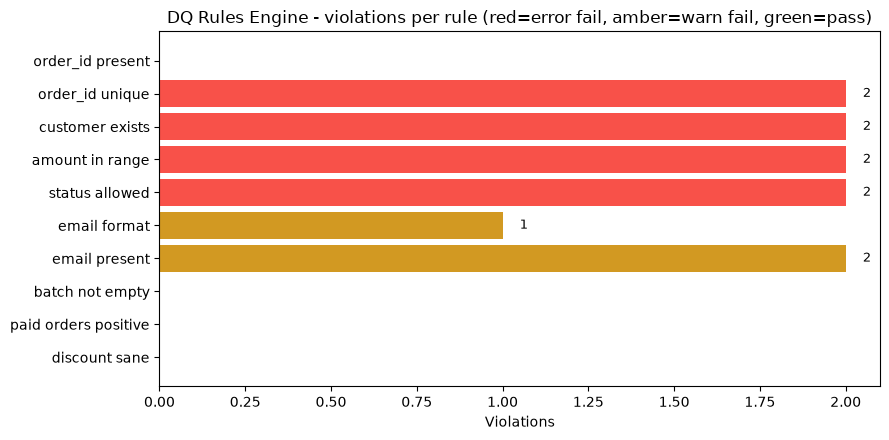

In [5]:
summary = summarize(results)

colours = []
for _, row in summary.iterrows():
    if row["status"] == "PASS":
        colours.append("#2EA043")           # green - passed
    elif row["severity"] == "error":
        colours.append("#F85149")           # red - failing error
    else:
        colours.append("#D29922")           # amber - failing warn

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(summary["rule"], summary["violations"], color=colours)
ax.invert_yaxis()
ax.set_xlabel("Violations")
ax.set_title("DQ Rules Engine - violations per rule (red=error fail, amber=warn fail, green=pass)")
for i, v in enumerate(summary["violations"]):
    if v:
        ax.text(v + 0.05, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("violations_per_rule.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

- Rules are **plain dicts** - the same object that can live in YAML or a governance table, now runnable on every batch instead of rotting on a wiki.
- Eight rule types cover the common breaks: null, uniqueness, range, allowed set, regex, referential/foreign key, row count, and a custom expression escape hatch for cross-column business logic.
- Every result is **explainable**: pass/fail, a violation count, sample offending values, and a plain-English message - so a steward can trust and triage the alert.
- The **error vs warn** split lets a pipeline gate on real breaks while still logging softer smells, and a rule against a missing column fails gracefully instead of crashing the run.


## Try your own data

Uncomment, point at your CSV, and adjust the rules to your columns.


In [6]:
# import pandas as pd
# my_df = pd.read_csv("your_data.csv")
#
# my_rules = [
#     {"name": "id present", "type": "not_null", "column": "id"},
#     {"name": "id unique", "type": "unique", "column": "id"},
#     {"name": "price in range", "type": "in_range", "column": "price", "min": 0, "max": 1e6},
#     {"name": "region allowed", "type": "allowed_values", "column": "region",
#      "values": ["North", "South", "East", "West"], "severity": "warn"},
#     # foreign_key: {"type": "foreign_key", "column": "customer_id", "reference": list_of_valid_ids}
#     # expression:  {"type": "expression", "expr": "end_date >= start_date"}
# ]
#
# my_results = run_rules(my_df, my_rules)
# display(summarize(my_results))
# print(rollup(my_results))

---

**Day 92 - DQ Rules Engine** - part of the Data Quality & Governance Suite.

Rules are heuristics a human owns: a flagged value may be a legitimate exception, and a rule set only catches what it was told to check. Treat results as a prioritised review queue, not an auto-reject gate.

Repo: [github.com/phoebefu6/phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)
